# Yield Analysis: English Summary

This notebook is a presentation-friendly summary of the `yield` analysis.
It does not rerun the full pipeline. Instead, it reads the locked result tables that were already produced in the main analysis notebooks and shows the key figures, code, and outputs in one place.


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'results').exists() and (ROOT.parent / 'results').exists():
    ROOT = ROOT.parent

YIELD_DIR = ROOT / 'results' / 'yield'
FIG_DIR = YIELD_DIR / 'figures'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

print('Yield results directory:', YIELD_DIR)
print('Figure directory:', FIG_DIR)


Yield results directory: /Users/liyuang/Desktop/STAT628/installment3/results/yield
Figure directory: /Users/liyuang/Desktop/STAT628/installment3/results/yield/figures


## Question

The yield section asks three related questions:

1. Does heat treatment change cranberry yield outcomes?
2. Are the effects similar in the `long-term` and `acute` experiments?
3. Do cultivar and heat intensity modify those effects?

We study three outcomes separately:
- `healthy_weight_g`
- `pct_rotten_count`
- `pct_rotten_weight`

## What We Did

1. Cleaned and locked the paired yield datasets.
2. Used `heat - control` paired differences for descriptive summaries.
3. Used mixed-effects models as the primary inference framework.

Model specifications:
- Long-term: `outcome ~ C(cultivar) * C(heat_trt) + (1 | cultivar:set_id)`
- Acute: `outcome ~ C(cultivar) * C(heat_level) * C(is_control) + (1 | cultivar:heat_level:replicate)`


In [2]:
longterm_summary = pd.read_csv(YIELD_DIR / 'yield_longterm_summary.csv')
acute_summary = pd.read_csv(YIELD_DIR / 'yield_acute_summary.csv')
longterm_terms = pd.read_csv(YIELD_DIR / 'yield_longterm_mixedlm_wald_terms.csv')
acute_terms = pd.read_csv(YIELD_DIR / 'yield_acute_mixedlm_wald_terms.csv')
longterm_coef = pd.read_csv(YIELD_DIR / 'yield_longterm_mixedlm_coefficients.csv')
acute_coef = pd.read_csv(YIELD_DIR / 'yield_acute_mixedlm_coefficients.csv')

acute_summary_main = acute_summary[acute_summary['cultivar'].isna()].copy()
longterm_sig = longterm_terms[(longterm_terms['term'] != 'Intercept') & (longterm_terms['p_value'] < 0.05)].copy()
acute_sig = acute_terms[(acute_terms['term'] != 'Intercept') & (acute_terms['p_value'] < 0.05)].copy()

print('Long-term paired summary')
display(longterm_summary)

print('Acute paired summary by heat level')
display(acute_summary_main)

print('Significant long-term mixed-model terms (p < 0.05)')
display(longterm_sig)

print('Significant acute mixed-model terms (p < 0.05)')
display(acute_sig)


Long-term paired summary


,outcome,n_pairs,mean_diff_heat_minus_control,sd_diff,se_diff,t_stat,p_value,cultivar
0,healthy_weight_g,8,-61.663750,170.539352,60.294766,-1.022705,0.340485,NaN
1,pct_rotten_count,8,-0.039676,0.034848,0.012321,-3.220261,0.014648,NaN
2,pct_rotten_weight,8,-0.015153,0.025320,0.008952,-1.692754,0.134336,NaN
3,healthy_weight_g,4,-125.912500,198.936051,99.468026,-1.265859,0.294933,MQ
4,pct_rotten_count,4,-0.032215,0.031348,0.015674,-2.055353,0.132083,MQ
5,pct_rotten_weight,4,-0.025494,0.028749,0.014375,-1.773581,0.174238,MQ
6,healthy_weight_g,4,2.585000,131.448115,65.724057,0.039331,0.971097,St
7,pct_rotten_count,4,-0.047137,0.041261,0.020631,-2.284784,0.106466,St
8,pct_rotten_weight,4,-0.004812,0.019602,0.009801,-0.491026,0.657085,St


Acute paired summary by heat level


,heat_level,outcome,n_pairs,mean_diff_heat_minus_control,sd_diff,se_diff,t_stat,p_value,cultivar
0,A,healthy_weight_g,6,-175.710000,166.119759,67.818108,-2.590901,0.048784,NaN
1,A,pct_rotten_count,6,0.129401,0.091559,0.037379,3.461867,0.018006,NaN
2,A,pct_rotten_weight,6,0.086697,0.095625,0.039039,2.220776,0.077053,NaN
3,B,healthy_weight_g,6,-64.003333,232.157895,94.778064,-0.675297,0.529450,NaN
4,B,pct_rotten_count,6,0.069407,0.053111,0.021683,3.201021,0.023968,NaN
5,B,pct_rotten_weight,6,0.053873,0.044758,0.018272,2.948324,0.031947,NaN
6,C,healthy_weight_g,6,-216.546667,46.541671,19.000558,-11.396858,0.000091,NaN
7,C,pct_rotten_count,6,0.086920,0.081554,0.033294,2.610645,0.047633,NaN
8,C,pct_rotten_weight,6,0.074413,0.049505,0.020210,3.681933,0.014265,NaN
9,D,healthy_weight_g,6,-165.075000,299.745494,122.370586,-1.348976,0.235215,NaN


Significant long-term mixed-model terms (p < 0.05)


,model_name,outcome,term,statistic,df_constraint,p_value
1,longterm_mixedlm,healthy_weight_g,C(cultivar),18.932774,1.0,0.000014
2,longterm_mixedlm,healthy_weight_g,C(heat_trt),4.111836,1.0,0.042584
6,longterm_mixedlm,pct_rotten_count,C(heat_trt),4.337525,1.0,0.037281
9,longterm_mixedlm,pct_rotten_weight,C(cultivar),11.374381,1.0,0.000745
10,longterm_mixedlm,pct_rotten_weight,C(heat_trt),5.726443,1.0,0.016711


Significant acute mixed-model terms (p < 0.05)


,model_name,outcome,term,statistic,df_constraint,p_value
3,acute_mixedlm,healthy_weight_g,C(is_control),5.059529,1.0,0.024491
11,acute_mixedlm,pct_rotten_count,C(is_control),5.565990,1.0,0.018313


In [3]:
key_longterm_coef = longterm_coef[
    longterm_coef['term'].isin(['C(cultivar)[T.St]', 'C(heat_trt)[T.OTC]'])
][['outcome', 'term', 'estimate', 'p_value', 'ci_low', 'ci_high']]

key_acute_coef = acute_coef[
    acute_coef['term'].eq('C(is_control)[T.1]')
][['outcome', 'term', 'estimate', 'p_value', 'ci_low', 'ci_high']]

print('Direction of key long-term effects')
display(key_longterm_coef)

print('Direction of the acute control-vs-treatment effect')
display(key_acute_coef)


Direction of key long-term effects


,outcome,term,estimate,p_value,ci_low,ci_high
1,healthy_weight_g,C(cultivar)[T.St],-279.695000,0.000014,-405.681982,-153.708018
2,healthy_weight_g,C(heat_trt)[T.OTC],-125.912500,0.042584,-247.614880,-4.210120
6,pct_rotten_count,C(cultivar)[T.St],0.022496,0.145846,-0.007821,0.052814
7,pct_rotten_count,C(heat_trt)[T.OTC],-0.032215,0.037281,-0.062533,-0.001898
11,pct_rotten_weight,C(cultivar)[T.St],-0.036481,0.000745,-0.057681,-0.015280
12,pct_rotten_weight,C(heat_trt)[T.OTC],-0.025494,0.016711,-0.046375,-0.004613


Direction of the acute control-vs-treatment effect


,outcome,term,estimate,p_value,ci_low,ci_high
5,healthy_weight_g,C(is_control)[T.1],225.693333,0.024491,29.035267,422.351400
22,pct_rotten_count,C(is_control)[T.1],-0.112258,0.018313,-0.205518,-0.018998
39,pct_rotten_weight,C(is_control)[T.1],-0.080837,0.074037,-0.169529,0.007855


## Long-Term Results

Interpretation:
- Long-term heat treatment is associated with lower healthy fruit weight and lower rotten proportions in several outcomes.
- Cultivar is also important, especially for `healthy_weight_g` and `pct_rotten_weight`.
- The interaction between cultivar and treatment is not strong in the long-term models, so the main story is driven more by treatment and cultivar main effects than by strong effect modification.


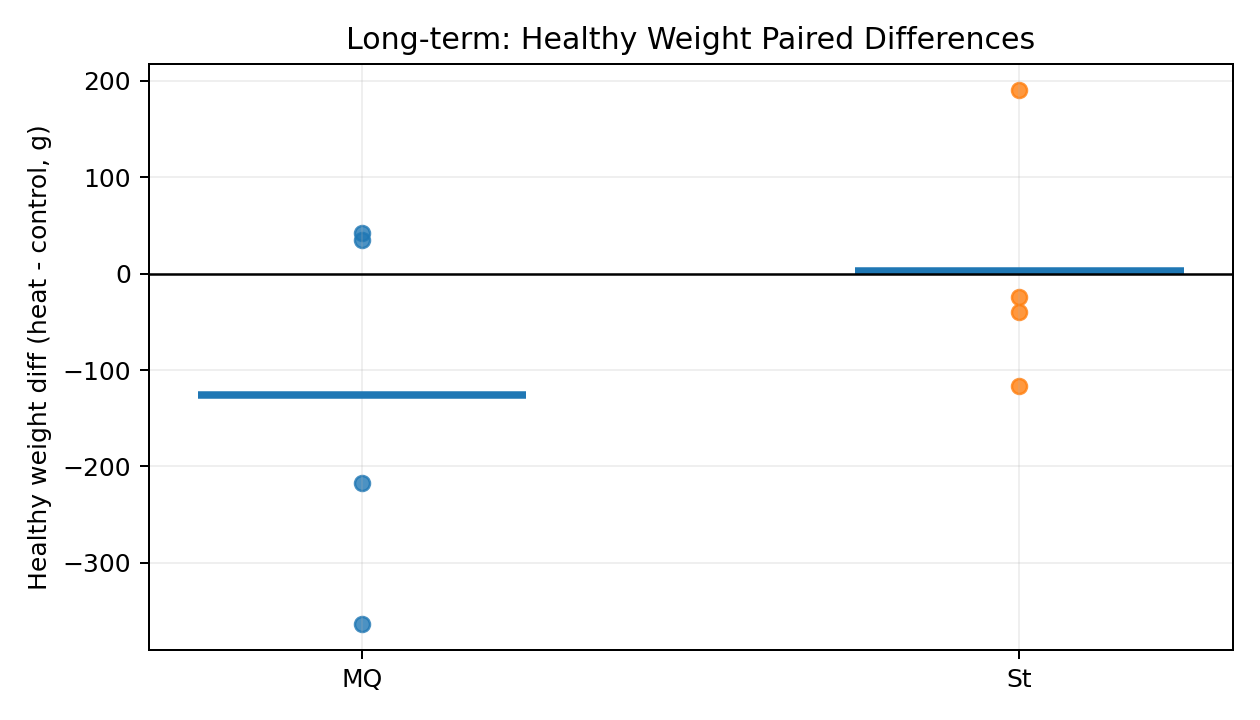

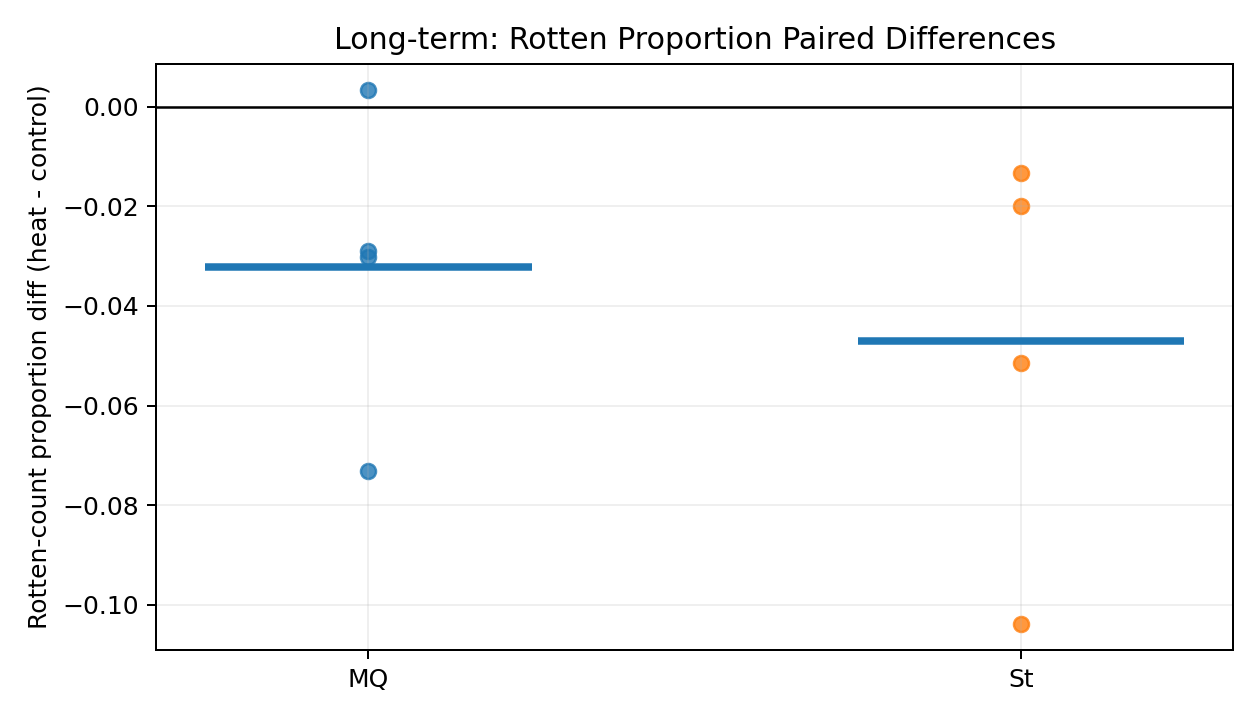

In [4]:
display(Image(filename=str(FIG_DIR / 'yield_longterm_healthy_weight_diff.png')))
display(Image(filename=str(FIG_DIR / 'yield_longterm_rotten_count_diff.png')))


## Acute Results

Interpretation:
- In the acute experiment, the clearest signal is the treatment-vs-control contrast.
- Heat treatment tends to reduce `healthy_weight_g` and increase rotten fruit proportions.
- At the whole-model level, heat level and higher-order interactions are not strongly significant, so the acute story is mainly a short-term treatment effect rather than a highly structured heat-level interaction.


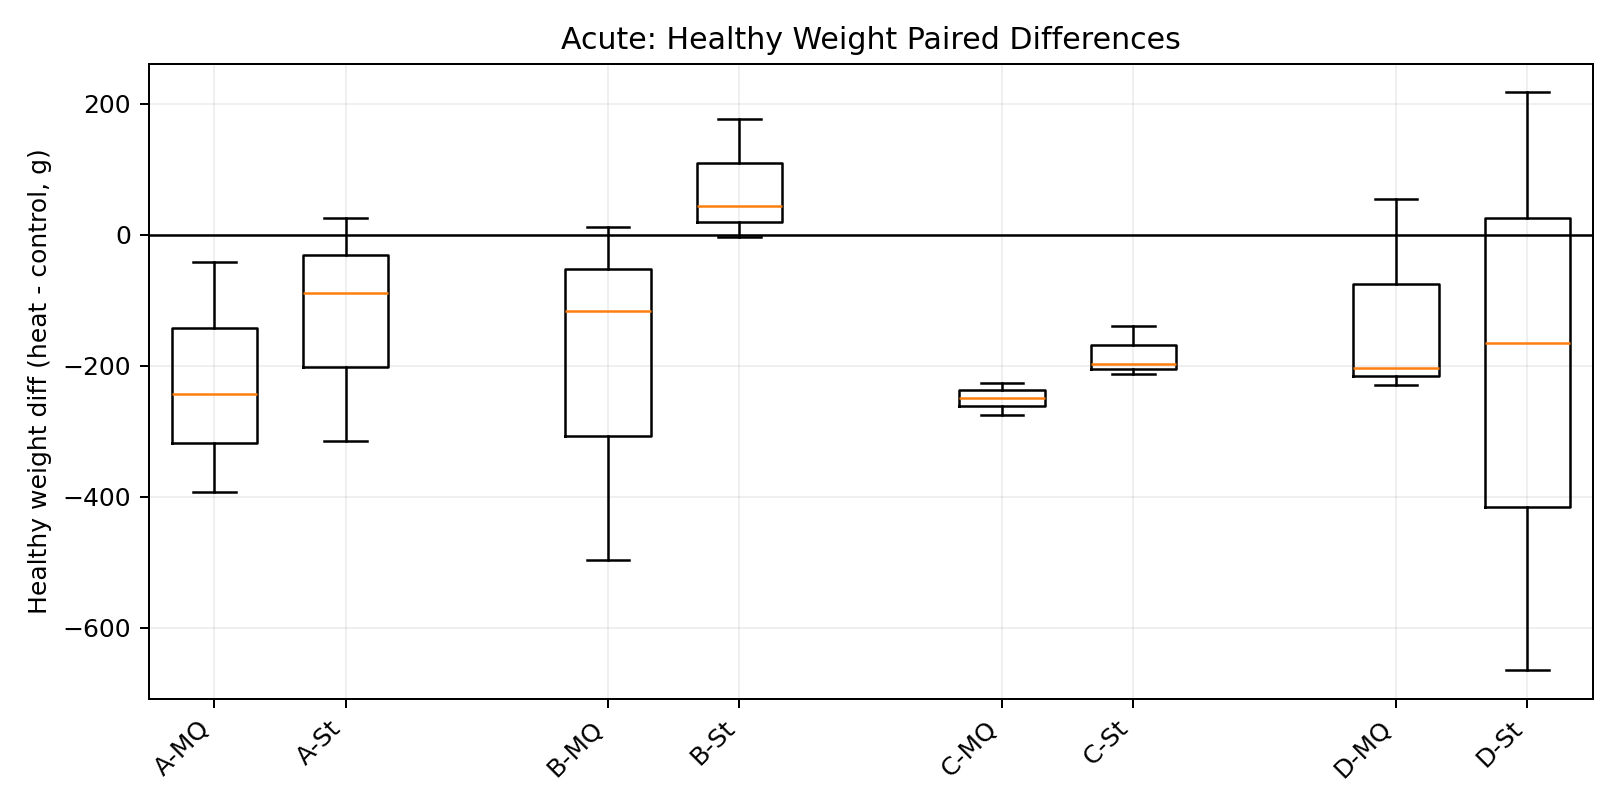

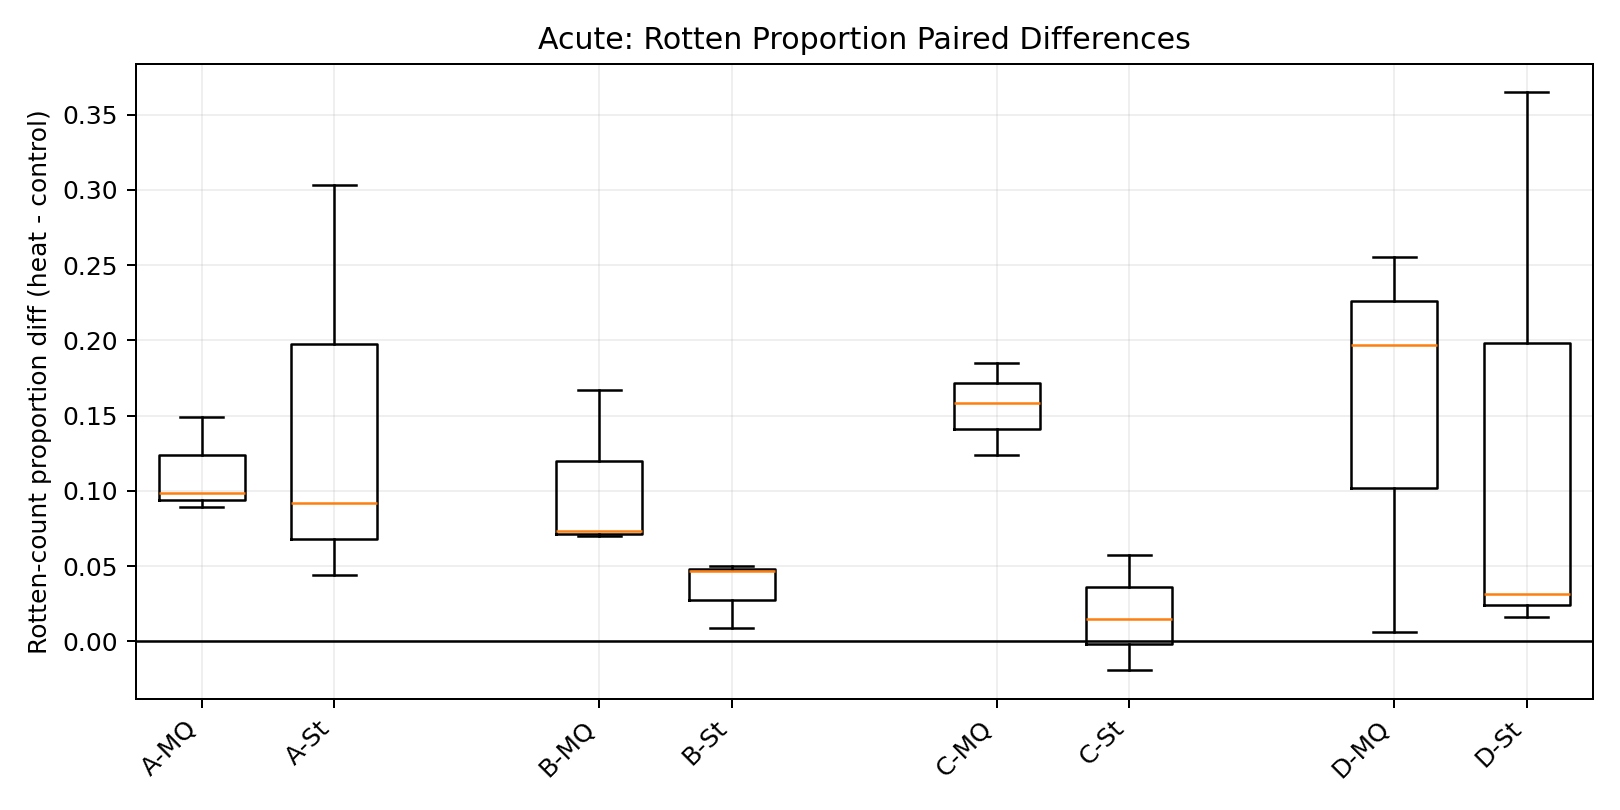

In [5]:
display(Image(filename=str(FIG_DIR / 'yield_acute_healthy_weight_diff_boxplot.png')))
display(Image(filename=str(FIG_DIR / 'yield_acute_rotten_count_diff_boxplot.png')))


In [6]:
overall_longterm = longterm_summary[longterm_summary['cultivar'].isna()].copy()
acute_main = acute_summary[acute_summary['cultivar'].isna()].copy()

print('English takeaways')
print('- Long-term: heat treatment and cultivar both show important main effects.')
print('- Long-term: healthy weight decreases under OTC, while rotten-count and rotten-weight proportions also decrease in the fitted model.')
print('- Acute: treatment vs control is the most stable signal across outcomes.')
print('- Acute: healthy weight is lower under heat treatment, and rotten proportions are generally higher under heat treatment.')
print('- The strongest acute paired-difference result for healthy weight appears at heat level C.')
print('- The acute rotten-weight model is weaker than the healthy-weight and rotten-count models, but its direction is still consistent with more rot under treatment.')

print('\nOverall long-term paired differences (heat - control)')
display(overall_longterm[['outcome', 'mean_diff_heat_minus_control', 'p_value']])

print('Overall acute paired differences by heat level (heat - control)')
display(acute_main[['heat_level', 'outcome', 'mean_diff_heat_minus_control', 'p_value']])


English takeaways
- Long-term: heat treatment and cultivar both show important main effects.
- Long-term: healthy weight decreases under OTC, while rotten-count and rotten-weight proportions also decrease in the fitted model.
- Acute: treatment vs control is the most stable signal across outcomes.
- Acute: healthy weight is lower under heat treatment, and rotten proportions are generally higher under heat treatment.
- The strongest acute paired-difference result for healthy weight appears at heat level C.
- The acute rotten-weight model is weaker than the healthy-weight and rotten-count models, but its direction is still consistent with more rot under treatment.

Overall long-term paired differences (heat - control)


,outcome,mean_diff_heat_minus_control,p_value
0,healthy_weight_g,-61.663750,0.340485
1,pct_rotten_count,-0.039676,0.014648
2,pct_rotten_weight,-0.015153,0.134336


Overall acute paired differences by heat level (heat - control)


,heat_level,outcome,mean_diff_heat_minus_control,p_value
0,A,healthy_weight_g,-175.710000,0.048784
1,A,pct_rotten_count,0.129401,0.018006
2,A,pct_rotten_weight,0.086697,0.077053
3,B,healthy_weight_g,-64.003333,0.529450
4,B,pct_rotten_count,0.069407,0.023968
5,B,pct_rotten_weight,0.053873,0.031947
6,C,healthy_weight_g,-216.546667,0.000091
7,C,pct_rotten_count,0.086920,0.047633
8,C,pct_rotten_weight,0.074413,0.014265
9,D,healthy_weight_g,-165.075000,0.235215


## Final Conclusion

Overall, the yield analysis suggests that heat treatment does affect cranberry outcomes, but the pattern depends on the experiment type.

- In the `acute` experiment, heat acts like a short-term stressor: healthy fruit weight tends to drop and rotten proportions tend to rise.
- In the `long-term` experiment, treatment effects are still present, but they are more mixed across outcomes and are influenced by cultivar.
- Across both experiments, the evidence for strong global interaction structure is limited, so the safest report emphasis is on the main treatment effects.
